In [1]:
!pip install gymnasium

   ---------------------------------------- 0.0/953.9 kB ? eta -:--:--
   --------------------- ------------------ 524.3/953.9 kB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 953.9/953.9 kB 4.1 MB/s  0:00:00

   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   ---------------------------------------- 2/2 [gymnasium]



In [2]:
import gymnasium as gym
import numpy as np
import random
import pickle
import matplotlib.pyplot as plt

In [4]:
env=gym.make("Taxi-v4")
print("observation space: ",env.observation_space)
print("action space: ",env.action_space)

observation space:  Discrete(500)
action space:  Discrete(6)


In [5]:
state_size = env.observation_space.n
action_size = env.action_space.n
q_table = np.zeros((state_size, action_size))
print(q_table.shape)

(500, 6)


In [6]:
learning_rate=0.1
gamma=0.99
epsilon=1.0
epsilon_decay=0.995
epsilon_min=0.01
episodes=10000
max_steps=100

In [7]:
rewards=[]
for episode in range(episodes):
    state, info = env.reset()
    total_reward = 0
    done = False
    for step in range(max_steps):
        if random.uniform(0,1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        old_value = q_table[state, action]
        next_max = np.max(q_table[next_state])
        new_value = old_value + learning_rate * (reward + gamma * next_max - old_value)
        q_table[state, action] = new_value
        state = next_state
        total_reward += reward
        if done:
            break
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rewards.append(total_reward)
    if (episode+1)%1000==0:
        print(f"Episode {episode+1} Reward = {total_reward}")

Episode 1000 Reward = -59
Episode 2000 Reward = 4
Episode 3000 Reward = 7
Episode 4000 Reward = 5
Episode 5000 Reward = 10
Episode 6000 Reward = 11
Episode 7000 Reward = 1
Episode 8000 Reward = 9
Episode 9000 Reward = 6
Episode 10000 Reward = 8


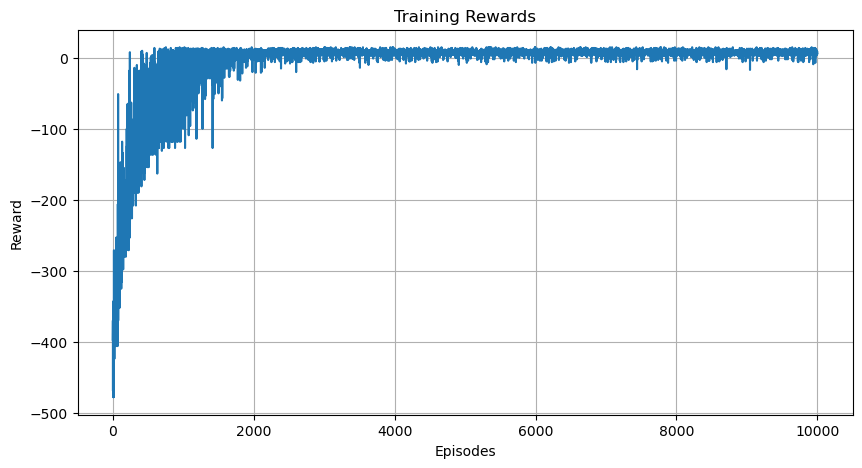

In [12]:
plt.figure(figsize=(10,5))
plt.plot(rewards)
plt.title("Training Rewards")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.grid()
plt.show()

In [10]:
with open("q_table.pkl","wb") as file:
    pickle.dump(q_table,file)
print("Model Saved Successfully")

Model Saved Successfully


In [11]:
print(q_table)

[[ 0.          0.          0.          0.          0.          0.        ]
 [-0.59825619 -3.51998028 -2.30229885 -3.54888144  9.6220697  -6.83241975]
 [-2.33761675 -0.7059282  -2.20028187 -2.21609321 14.11880599 -2.97092662]
 ...
 [-0.99271887 -0.47341008 -0.96732696 -0.93838801 -5.42172599 -4.85320993]
 [-2.38139826 -2.41587422 -2.36720851 -2.43804458 -2.96524384 -3.61928113]
 [-0.1        -0.19       -0.1         5.97372107  0.         -1.9       ]]
